In [2]:
import sys; sys.path.append("../") # For relative imports

from utils.experiment_utils import *

%load_ext autoreload
%autoreload 2

C:\Users\24856613\AppData\Local\Temp\ipykernel_7932\888676055.py:175: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved: ./figures/ddr\ddr_option1_covgap_APS.pdf
Saved: ./figures/ddr\ddr_option1_covgap_APS.png


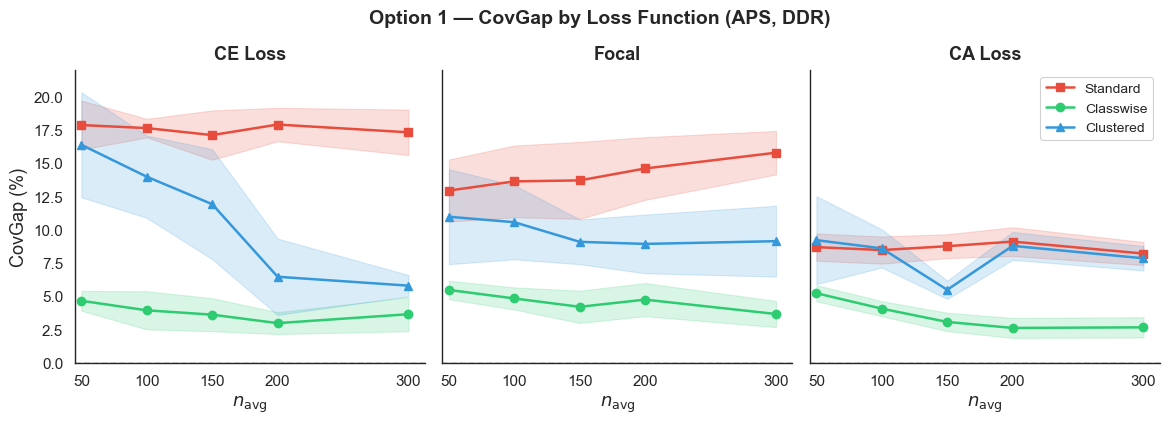

In [39]:
# ============================================================
#  plot_option1_final_v2.py
#  Option 1 — 1x3 grid: CE Loss | Focal Loss | CA Loss
#  Fixed: APS score function, CovGap metric, DDR dataset
#  Style: matches reference figure
#
#  Usage: run after your setup cells (imports, helpers, settings)
# ============================================================

import sys; sys.path.append("../")
from utils.experiment_utils import *
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ── Settings ──────────────────────────────────────────────────────────────────
save_folder       = r'C:/Anum/Experiments/0002-Conformal-Pred-Classification/GitHub/training/new/conformal/results/paper/varying_n/'
dataset_list      = ['ddr-ce', 'ddr-focal', 'ddr-cp-aware']
cal_sampling      = 'random'
n_list            = [50, 100, 150, 200,300]
method_list       = ['standard', 'classwise', 'cluster_random']
expected_num_seeds = 5

SCORE     = 'RAPS'
METRIC    = 'class_cov_gap'
FONT_SIZE = 13

# ── Display names ─────────────────────────────────────────────────────────────
loss_to_label = {
    'ddr-ce':       'CE Loss',
    'ddr-cp-aware': 'CA Loss',
    'ddr-focal' : 'Focal'
}

method_to_name = {
    'standard':       'Standard',
    'classwise':      'Classwise',
    'cluster_random': 'Clustered',
}

method_to_color = {
    'standard':       '#e74c3c',
    'classwise':      '#2ecc71',
    'cluster_random': '#3498db',
}

method_to_marker = {
    'standard':       's',
    'classwise':      'o',
    'cluster_random': '^',
}

# ── Plot style ────────────────────────────────────────────────────────────────
sns.set_style('white', {
    'axes.spines.right': False,
    'axes.spines.top':   False,
   # 'grid.linestyle':    '--',
   # 'grid.alpha':        0.4,
})
sns.set_context('paper')

# ── Line plot helper ──────────────────────────────────────────────────────────
def make_line_plot(aggregated_results, ax, metric):
    for method in method_list:
        x  = n_list
        y  = np.array(aggregated_results[f'{metric}_mean'][method])
        se = np.array(aggregated_results[f'{metric}_se'][method])

        ax.plot(
            x, y,
            marker=method_to_marker[method],
            label=method_to_name[method],
            color=method_to_color[method],
            markersize=6,
            linewidth=1.8,
            zorder=3
        )
        ax.fill_between(
            x,
            y - 1.96 * se,
            y + 1.96 * se,
            color=method_to_color[method],
            alpha=0.18,
            zorder=2
        )

    ax.set_xlabel('$n_{\\mathrm{avg}}$', fontsize=FONT_SIZE)
    ax.set_xticks(n_list)
    ax.set_xlim(left=45)
    ax.tick_params(labelsize=FONT_SIZE - 2)

# ── Main plot ─────────────────────────────────────────────────────────────────
fig, axs = plt.subplots(
    1, len(dataset_list),
    figsize=(14, 3.8),
    gridspec_kw={'wspace': 0.05}
)

for j, dataset_name in enumerate(dataset_list):

    ax = axs[j]

    # Initialise result containers
    aggregated_results = {
        f'{METRIC}_mean': {m: [] for m in method_list},
        f'{METRIC}_se':   {m: [] for m in method_list},
    }

    # Aggregate across n values
    for n_totalcal in n_list:

        curr_folder = (
            f'{save_folder}/{dataset_name}/{cal_sampling}_calset'
            f'/n_totalcal={n_totalcal}/score={SCORE}'
        )

        df = average_results_across_seeds(
            curr_folder,
            print_results=False,
            display_table=False,
            methods=method_list,
            max_seeds=expected_num_seeds
        )

        for method in method_list:
            for suffix in ['mean', 'se']:
                aggregated_results[f'{METRIC}_{suffix}'][method].append(
                    df[f'{METRIC}_{suffix}'][df['method'] == method].values[0]
                )

    # Draw
    make_line_plot(aggregated_results, ax, METRIC)

    # Panel title
    ax.set_title(
        loss_to_label[dataset_name],
        fontsize=FONT_SIZE,
        fontweight='bold',
        pad=8
    )

    # Y-axis: label + ticks on leftmost only
    if j == 0:
        ax.set_ylabel('CovGap (%)', fontsize=FONT_SIZE)
    else:
        ax.set_ylabel('')
        ax.set_yticks([])
        ax.tick_params(left=False)

    ax.set_ylim(0, 22)
    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.3, zorder=1)

    # Remove right/top spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Legend inside top-right of rightmost panel
axs[-1].legend(
    frameon=True,
    fontsize=FONT_SIZE - 3,
    loc='upper right',
    framealpha=0.9,
    edgecolor='#cccccc'
)

# Main title
fig.suptitle(
    'Option 1 — CovGap by Loss Function (APS, DDR)',
    fontsize=FONT_SIZE + 1,
    fontweight='bold',
    y=1.04
)

plt.tight_layout()

# ── Save ──────────────────────────────────────────────────────────────────────
out_dir = './figures/ddr'
os.makedirs(out_dir, exist_ok=True)

for ext in ['pdf', 'png']:
    save_path = os.path.join(out_dir, f'ddr_option1_covgap_APS.{ext}')
    plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
    print(f'Saved: {save_path}')

plt.show()

C:\Users\24856613\AppData\Local\Temp\ipykernel_7932\2838743933.py:175: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved: ./figures/isic\isic_option1_avgsize_RAPS.pdf
Saved: ./figures/isic\isic_option1_avgsize_RAPS.png


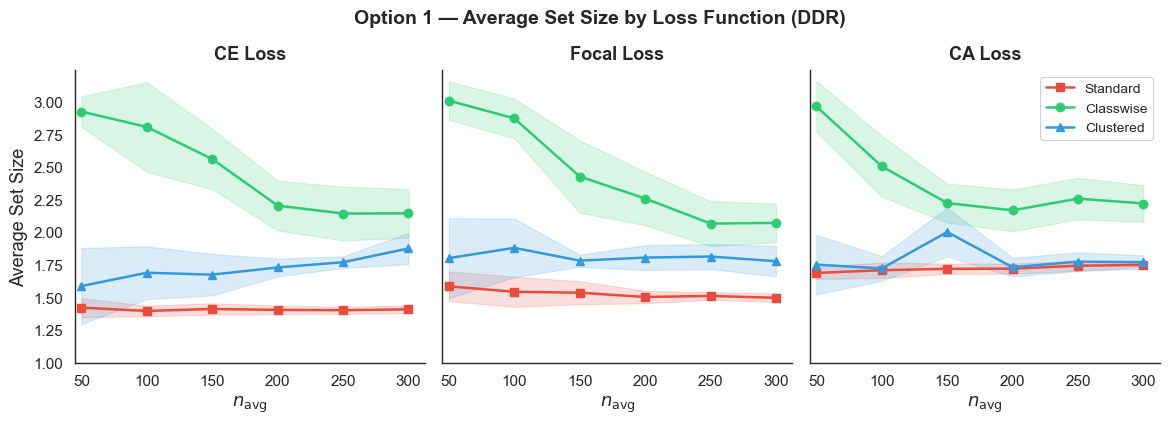

In [40]:
# ============================================================
#  plot_option1_final_v2_avgsize.py
#  Option 1 — 1x3 grid: CE Loss | Focal Loss | CA Loss
#  Fixed: APS score function, AvgSize metric, ISIC dataset
#  Style: matches reference figure
# ============================================================

import sys; sys.path.append("../")
from utils.experiment_utils import *
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ── Settings ──────────────────────────────────────────────────────────────────
save_folder       = r'C:/Anum/Experiments/0002-Conformal-Pred-Classification/GitHub/training/new/conformal/results/paper/varying_n/'
dataset_list      = ['ddr-ce', 'ddr-focal', 'ddr-cp-aware']
cal_sampling      = 'random'
n_list            = [50, 100, 150, 200, 250, 300]
method_list       = ['standard', 'classwise', 'cluster_random']
expected_num_seeds = 5

SCORE     = 'RAPS'
# UPDATE THIS if your dataframe uses a different key (e.g., 'avg_size', 'mean_size')
METRIC    = 'avg_set_size' 
FONT_SIZE = 13

# ── Display names ─────────────────────────────────────────────────────────────
loss_to_label = {
    'ddr-ce':       'CE Loss',
    'ddr-cp-aware': 'CA Loss',
    'ddr-focal' :   'Focal Loss'
}

method_to_name = {
    'standard':       'Standard',
    'classwise':      'Classwise',
    'cluster_random': 'Clustered',
}

method_to_color = {
    'standard':       '#e74c3c',
    'classwise':      '#2ecc71',
    'cluster_random': '#3498db',
}

method_to_marker = {
    'standard':       's',
    'classwise':      'o',
    'cluster_random': '^',
}

# ── Plot style ────────────────────────────────────────────────────────────────
sns.set_style('white', {
    'axes.spines.right': False,
    'axes.spines.top':   False,
    #'grid.linestyle':    '--',
    #'grid.alpha':        0.4,
})
sns.set_context('paper')

# ── Line plot helper ──────────────────────────────────────────────────────────
def make_line_plot(aggregated_results, ax, metric):
    for method in method_list:
        x  = n_list
        y  = np.array(aggregated_results[f'{metric}_mean'][method])
        se = np.array(aggregated_results[f'{metric}_se'][method])

        ax.plot(
            x, y,
            marker=method_to_marker[method],
            label=method_to_name[method],
            color=method_to_color[method],
            markersize=6,
            linewidth=1.8,
            zorder=3
        )
        ax.fill_between(
            x,
            y - 1.96 * se,
            y + 1.96 * se,
            color=method_to_color[method],
            alpha=0.18,
            zorder=2
        )

    ax.set_xlabel('$n_{\\mathrm{avg}}$', fontsize=FONT_SIZE)
    ax.set_xticks(n_list)
    ax.set_xlim(left=45)
    ax.tick_params(labelsize=FONT_SIZE - 2)

# ── Main plot ─────────────────────────────────────────────────────────────────
fig, axs = plt.subplots(
    1, len(dataset_list),
    figsize=(14, 3.8),
    gridspec_kw={'wspace': 0.05}
)

for j, dataset_name in enumerate(dataset_list):

    ax = axs[j]

    # Initialise result containers
    aggregated_results = {
        f'{METRIC}_mean': {m: [] for m in method_list},
        f'{METRIC}_se':   {m: [] for m in method_list},
    }

    # Aggregate across n values
    for n_totalcal in n_list:

        curr_folder = (
            f'{save_folder}/{dataset_name}/{cal_sampling}_calset'
            f'/n_totalcal={n_totalcal}/score={SCORE}'
        )

        df = average_results_across_seeds(
            curr_folder,
            print_results=False,
            display_table=False,
            methods=method_list,
            max_seeds=expected_num_seeds
        )

        for method in method_list:
            for suffix in ['mean', 'se']:
                aggregated_results[f'{METRIC}_{suffix}'][method].append(
                    df[f'{METRIC}_{suffix}'][df['method'] == method].values[0]
                )

    # Draw
    make_line_plot(aggregated_results, ax, METRIC)

    # Panel title
    ax.set_title(
        loss_to_label[dataset_name],
        fontsize=FONT_SIZE,
        fontweight='bold',
        pad=8
    )

    # Y-axis: label + ticks on leftmost only
    if j == 0:
        ax.set_ylabel('Average Set Size', fontsize=FONT_SIZE)
    else:
        ax.set_ylabel('')
        ax.set_yticks([])
        ax.tick_params(left=False)

    # Allow matplotlib to autoscale the Y-axis based on the set sizes, 
    # but ensure it starts at 1 (the minimum possible set size).
    ax.set_ylim(bottom=1.0)

    # Remove right/top spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Legend inside top-right of rightmost panel
axs[-1].legend(
    frameon=True,
    fontsize=FONT_SIZE - 3,
    loc='upper right',
    framealpha=0.9,
    edgecolor='#cccccc'
)

# Main title (Updated to reflect AvgSize and ISIC based on the dataset_list)
fig.suptitle(
    'Option 1 — Average Set Size by Loss Function (DDR)',
    fontsize=FONT_SIZE + 1,
    fontweight='bold',
    y=1.04
)

plt.tight_layout()

# ── Save ──────────────────────────────────────────────────────────────────────
out_dir = './figures/isic'
os.makedirs(out_dir, exist_ok=True)

for ext in ['pdf', 'png']:
    save_path = os.path.join(out_dir, f'isic_option1_avgsize_{SCORE}.{ext}')
    plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
    print(f'Saved: {save_path}')

plt.show()

C:\Users\24856613\AppData\Local\Temp\ipykernel_7932\1682513854.py:175: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved: ./figures/ddr\ddr_option1_covgap_APS.pdf
Saved: ./figures/ddr\ddr_option1_covgap_APS.png


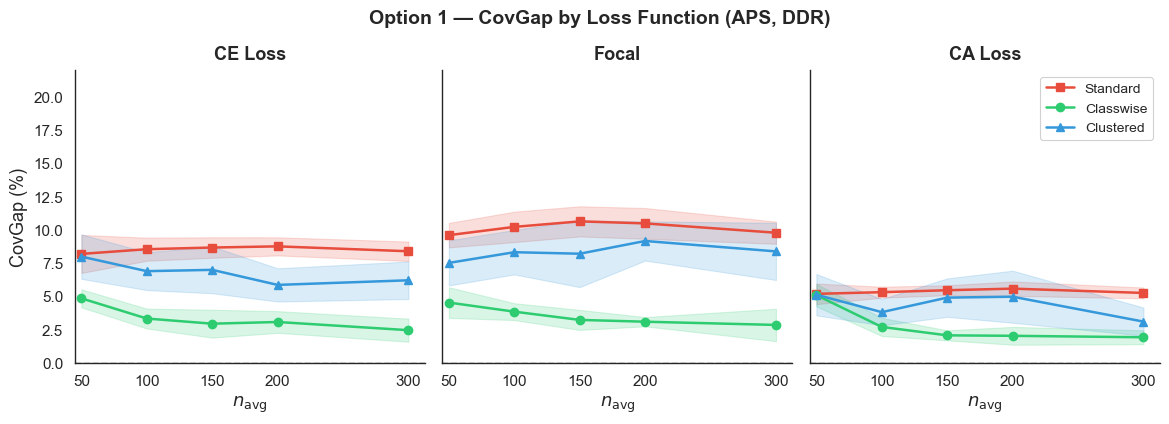

In [41]:
# ============================================================
#  plot_option1_final_v2.py
#  Option 1 — 1x3 grid: CE Loss | Focal Loss | CA Loss
#  Fixed: APS score function, CovGap metric, DDR dataset
#  Style: matches reference figure
#
#  Usage: run after your setup cells (imports, helpers, settings)
# ============================================================

import sys; sys.path.append("../")
from utils.experiment_utils import *
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ── Settings ──────────────────────────────────────────────────────────────────
save_folder       = r'C:/Anum/Experiments/0002-Conformal-Pred-Classification/GitHub/training/new/conformal/results/paper/varying_n/'
dataset_list      = ['dfuc-ce', 'dfuc-focal', 'dfuc-cp-aware']
cal_sampling      = 'random'
n_list            = [50, 100, 150, 200,300]
method_list       = ['standard', 'classwise', 'cluster_random']
expected_num_seeds = 5

SCORE     = 'RAPS'
METRIC    = 'class_cov_gap'
FONT_SIZE = 13

# ── Display names ─────────────────────────────────────────────────────────────
loss_to_label = {
    'dfuc-ce':       'CE Loss',
    'dfuc-cp-aware': 'CA Loss',
    'dfuc-focal' : 'Focal'
}

method_to_name = {
    'standard':       'Standard',
    'classwise':      'Classwise',
    'cluster_random': 'Clustered',
}

method_to_color = {
    'standard':       '#e74c3c',
    'classwise':      '#2ecc71',
    'cluster_random': '#3498db',
}

method_to_marker = {
    'standard':       's',
    'classwise':      'o',
    'cluster_random': '^',
}

# ── Plot style ────────────────────────────────────────────────────────────────
sns.set_style('white', {
    'axes.spines.right': False,
    'axes.spines.top':   False,
    #'grid.linestyle':    '--',
    #'grid.alpha':        0.4,
})
sns.set_context('paper')

# ── Line plot helper ──────────────────────────────────────────────────────────
def make_line_plot(aggregated_results, ax, metric):
    for method in method_list:
        x  = n_list
        y  = np.array(aggregated_results[f'{metric}_mean'][method])
        se = np.array(aggregated_results[f'{metric}_se'][method])

        ax.plot(
            x, y,
            marker=method_to_marker[method],
            label=method_to_name[method],
            color=method_to_color[method],
            markersize=6,
            linewidth=1.8,
            zorder=3
        )
        ax.fill_between(
            x,
            y - 1.96 * se,
            y + 1.96 * se,
            color=method_to_color[method],
            alpha=0.18,
            zorder=2
        )

    ax.set_xlabel('$n_{\\mathrm{avg}}$', fontsize=FONT_SIZE)
    ax.set_xticks(n_list)
    ax.set_xlim(left=45)
    ax.tick_params(labelsize=FONT_SIZE - 2)

# ── Main plot ─────────────────────────────────────────────────────────────────
fig, axs = plt.subplots(
    1, len(dataset_list),
    figsize=(14, 3.8),
    gridspec_kw={'wspace': 0.05}
)

for j, dataset_name in enumerate(dataset_list):

    ax = axs[j]

    # Initialise result containers
    aggregated_results = {
        f'{METRIC}_mean': {m: [] for m in method_list},
        f'{METRIC}_se':   {m: [] for m in method_list},
    }

    # Aggregate across n values
    for n_totalcal in n_list:

        curr_folder = (
            f'{save_folder}/{dataset_name}/{cal_sampling}_calset'
            f'/n_totalcal={n_totalcal}/score={SCORE}'
        )

        df = average_results_across_seeds(
            curr_folder,
            print_results=False,
            display_table=False,
            methods=method_list,
            max_seeds=expected_num_seeds
        )

        for method in method_list:
            for suffix in ['mean', 'se']:
                aggregated_results[f'{METRIC}_{suffix}'][method].append(
                    df[f'{METRIC}_{suffix}'][df['method'] == method].values[0]
                )

    # Draw
    make_line_plot(aggregated_results, ax, METRIC)

    # Panel title
    ax.set_title(
        loss_to_label[dataset_name],
        fontsize=FONT_SIZE,
        fontweight='bold',
        pad=8
    )

    # Y-axis: label + ticks on leftmost only
    if j == 0:
        ax.set_ylabel('CovGap (%)', fontsize=FONT_SIZE)
    else:
        ax.set_ylabel('')
        ax.set_yticks([])
        ax.tick_params(left=False)

    ax.set_ylim(0, 22)
    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.3, zorder=1)

    # Remove right/top spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Legend inside top-right of rightmost panel
axs[-1].legend(
    frameon=True,
    fontsize=FONT_SIZE - 3,
    loc='upper right',
    framealpha=0.9,
    edgecolor='#cccccc'
)

# Main title
fig.suptitle(
    'Option 1 — CovGap by Loss Function (APS, DDR)',
    fontsize=FONT_SIZE + 1,
    fontweight='bold',
    y=1.04
)

plt.tight_layout()

# ── Save ──────────────────────────────────────────────────────────────────────
out_dir = './figures/ddr'
os.makedirs(out_dir, exist_ok=True)

for ext in ['pdf', 'png']:
    save_path = os.path.join(out_dir, f'ddr_option1_covgap_APS.{ext}')
    plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
    print(f'Saved: {save_path}')

plt.show()

C:\Users\24856613\AppData\Local\Temp\ipykernel_7932\1709780278.py:175: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved: ./figures/isic\isic_option1_avgsize_RAPS.pdf
Saved: ./figures/isic\isic_option1_avgsize_RAPS.png


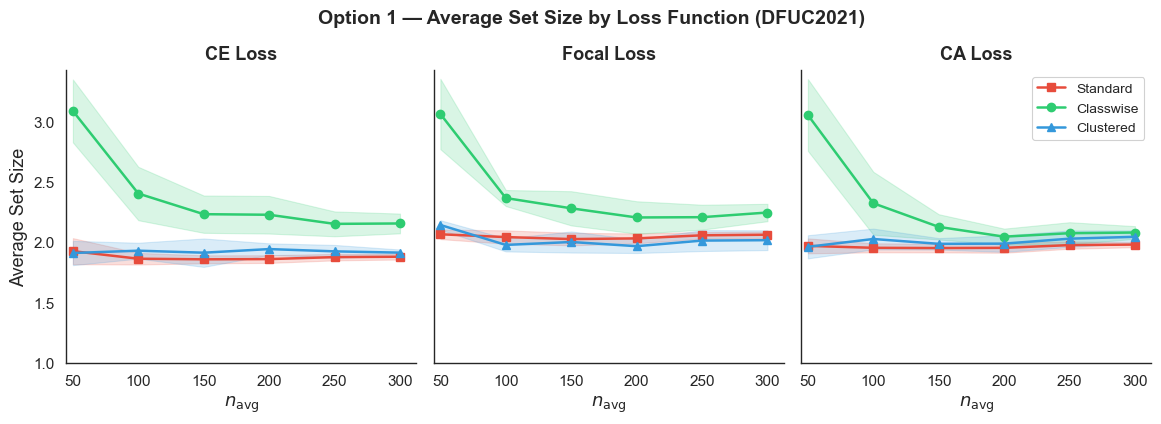

In [42]:
# ============================================================
#  plot_option1_final_v2_avgsize.py
#  Option 1 — 1x3 grid: CE Loss | Focal Loss | CA Loss
#  Fixed: APS score function, AvgSize metric, ISIC dataset
#  Style: matches reference figure
# ============================================================

import sys; sys.path.append("../")
from utils.experiment_utils import *
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ── Settings ──────────────────────────────────────────────────────────────────
save_folder       = r'C:/Anum/Experiments/0002-Conformal-Pred-Classification/GitHub/training/new/conformal/results/paper/varying_n/'
dataset_list      = ['dfuc-ce', 'dfuc-focal', 'dfuc-cp-aware']
cal_sampling      = 'random'
n_list            = [50, 100, 150, 200, 250, 300]
method_list       = ['standard', 'classwise', 'cluster_random']
expected_num_seeds = 5

SCORE     = 'RAPS'
# UPDATE THIS if your dataframe uses a different key (e.g., 'avg_size', 'mean_size')
METRIC    = 'avg_set_size' 
FONT_SIZE = 13

# ── Display names ─────────────────────────────────────────────────────────────
loss_to_label = {
    'dfuc-ce':       'CE Loss',
    'dfuc-cp-aware': 'CA Loss',
    'dfuc-focal' :   'Focal Loss'
}

method_to_name = {
    'standard':       'Standard',
    'classwise':      'Classwise',
    'cluster_random': 'Clustered',
}

method_to_color = {
    'standard':       '#e74c3c',
    'classwise':      '#2ecc71',
    'cluster_random': '#3498db',
}

method_to_marker = {
    'standard':       's',
    'classwise':      'o',
    'cluster_random': '^',
}

# ── Plot style ────────────────────────────────────────────────────────────────
sns.set_style('white', {
    'axes.spines.right': False,
    'axes.spines.top':   False,
    #'grid.linestyle':    '--',
    #'grid.alpha':        0.4,
})
sns.set_context('paper')

# ── Line plot helper ──────────────────────────────────────────────────────────
def make_line_plot(aggregated_results, ax, metric):
    for method in method_list:
        x  = n_list
        y  = np.array(aggregated_results[f'{metric}_mean'][method])
        se = np.array(aggregated_results[f'{metric}_se'][method])

        ax.plot(
            x, y,
            marker=method_to_marker[method],
            label=method_to_name[method],
            color=method_to_color[method],
            markersize=6,
            linewidth=1.8,
            zorder=3
        )
        ax.fill_between(
            x,
            y - 1.96 * se,
            y + 1.96 * se,
            color=method_to_color[method],
            alpha=0.18,
            zorder=2
        )

    ax.set_xlabel('$n_{\\mathrm{avg}}$', fontsize=FONT_SIZE)
    ax.set_xticks(n_list)
    ax.set_xlim(left=45)
    ax.tick_params(labelsize=FONT_SIZE - 2)

# ── Main plot ─────────────────────────────────────────────────────────────────
fig, axs = plt.subplots(
    1, len(dataset_list),
    figsize=(14, 3.8),
    gridspec_kw={'wspace': 0.05}
)

for j, dataset_name in enumerate(dataset_list):

    ax = axs[j]

    # Initialise result containers
    aggregated_results = {
        f'{METRIC}_mean': {m: [] for m in method_list},
        f'{METRIC}_se':   {m: [] for m in method_list},
    }

    # Aggregate across n values
    for n_totalcal in n_list:

        curr_folder = (
            f'{save_folder}/{dataset_name}/{cal_sampling}_calset'
            f'/n_totalcal={n_totalcal}/score={SCORE}'
        )

        df = average_results_across_seeds(
            curr_folder,
            print_results=False,
            display_table=False,
            methods=method_list,
            max_seeds=expected_num_seeds
        )

        for method in method_list:
            for suffix in ['mean', 'se']:
                aggregated_results[f'{METRIC}_{suffix}'][method].append(
                    df[f'{METRIC}_{suffix}'][df['method'] == method].values[0]
                )

    # Draw
    make_line_plot(aggregated_results, ax, METRIC)

    # Panel title
    ax.set_title(
        loss_to_label[dataset_name],
        fontsize=FONT_SIZE,
        fontweight='bold',
        pad=8
    )

    # Y-axis: label + ticks on leftmost only
    if j == 0:
        ax.set_ylabel('Average Set Size', fontsize=FONT_SIZE)
    else:
        ax.set_ylabel('')
        ax.set_yticks([])
        ax.tick_params(left=False)

    # Allow matplotlib to autoscale the Y-axis based on the set sizes, 
    # but ensure it starts at 1 (the minimum possible set size).
    ax.set_ylim(bottom=1.0)

    # Remove right/top spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Legend inside top-right of rightmost panel
axs[-1].legend(
    frameon=True,
    fontsize=FONT_SIZE - 3,
    loc='upper right',
    framealpha=0.9,
    edgecolor='#cccccc'
)

# Main title (Updated to reflect AvgSize and ISIC based on the dataset_list)
fig.suptitle(
    'Option 1 — Average Set Size by Loss Function (DFUC2021)',
    fontsize=FONT_SIZE + 1,
    fontweight='bold',
    y=1.04
)

plt.tight_layout()

# ── Save ──────────────────────────────────────────────────────────────────────
out_dir = './figures/isic'
os.makedirs(out_dir, exist_ok=True)

for ext in ['pdf', 'png']:
    save_path = os.path.join(out_dir, f'isic_option1_avgsize_{SCORE}.{ext}')
    plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
    print(f'Saved: {save_path}')

plt.show()

C:\Users\24856613\AppData\Local\Temp\ipykernel_7932\2416300868.py:175: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved: ./figures/ddr\ddr_option1_covgap_APS.pdf
Saved: ./figures/ddr\ddr_option1_covgap_APS.png


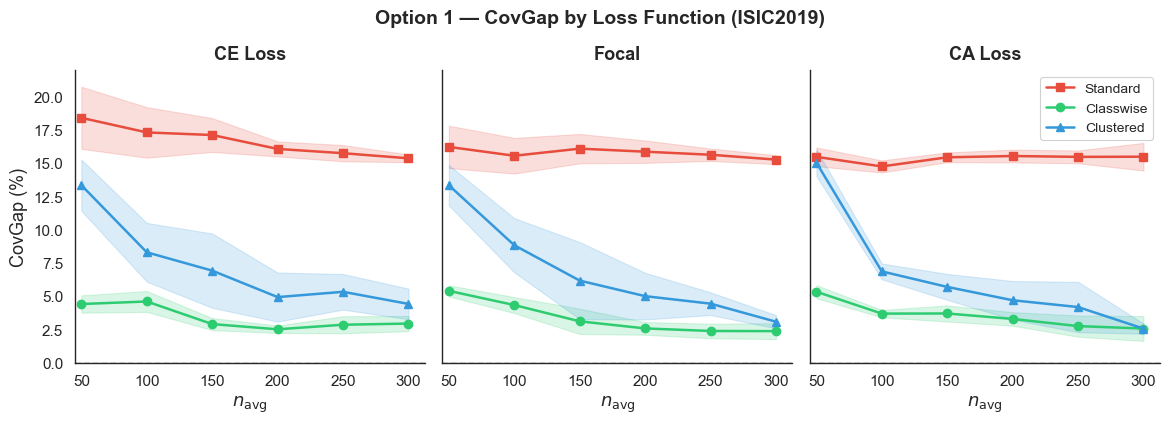

In [43]:
# ============================================================
#  plot_option1_final_v2.py
#  Option 1 — 1x3 grid: CE Loss | Focal Loss | CA Loss
#  Fixed: APS score function, CovGap metric, DDR dataset
#  Style: matches reference figure
#
#  Usage: run after your setup cells (imports, helpers, settings)
# ============================================================

import sys; sys.path.append("../")
from utils.experiment_utils import *
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ── Settings ──────────────────────────────────────────────────────────────────
save_folder       = r'C:/Anum/Experiments/0002-Conformal-Pred-Classification/GitHub/training/new/conformal/results/paper/varying_n/'
dataset_list      = ['isic-ce', 'isic-focal', 'isic-cp-aware']
cal_sampling      = 'random'
n_list            = [50, 100, 150, 200,250, 300]
method_list       = ['standard', 'classwise', 'cluster_random']
expected_num_seeds = 5

SCORE     = 'APS'
METRIC    = 'class_cov_gap'
FONT_SIZE = 13

# ── Display names ─────────────────────────────────────────────────────────────
loss_to_label = {
    'isic-ce':       'CE Loss',
    'isic-cp-aware': 'CA Loss',
    'isic-focal' : 'Focal'
}

method_to_name = {
    'standard':       'Standard',
    'classwise':      'Classwise',
    'cluster_random': 'Clustered',
}

method_to_color = {
    'standard':       '#e74c3c',
    'classwise':      '#2ecc71',
    'cluster_random': '#3498db',
}

method_to_marker = {
    'standard':       's',
    'classwise':      'o',
    'cluster_random': '^',
}

# ── Plot style ────────────────────────────────────────────────────────────────
sns.set_style('white', {
    'axes.spines.right': False,
    'axes.spines.top':   False,
    #'grid.linestyle':    '--',
    #'grid.alpha':        0.4,
})
sns.set_context('paper')

# ── Line plot helper ──────────────────────────────────────────────────────────
def make_line_plot(aggregated_results, ax, metric):
    for method in method_list:
        x  = n_list
        y  = np.array(aggregated_results[f'{metric}_mean'][method])
        se = np.array(aggregated_results[f'{metric}_se'][method])

        ax.plot(
            x, y,
            marker=method_to_marker[method],
            label=method_to_name[method],
            color=method_to_color[method],
            markersize=6,
            linewidth=1.8,
            zorder=3
        )
        ax.fill_between(
            x,
            y - 1.96 * se,
            y + 1.96 * se,
            color=method_to_color[method],
            alpha=0.18,
            zorder=2
        )

    ax.set_xlabel('$n_{\\mathrm{avg}}$', fontsize=FONT_SIZE)
    ax.set_xticks(n_list)
    ax.set_xlim(left=45)
    ax.tick_params(labelsize=FONT_SIZE - 2)

# ── Main plot ─────────────────────────────────────────────────────────────────
fig, axs = plt.subplots(
    1, len(dataset_list),
    figsize=(14, 3.8),
    gridspec_kw={'wspace': 0.05}
)

for j, dataset_name in enumerate(dataset_list):

    ax = axs[j]

    # Initialise result containers
    aggregated_results = {
        f'{METRIC}_mean': {m: [] for m in method_list},
        f'{METRIC}_se':   {m: [] for m in method_list},
    }

    # Aggregate across n values
    for n_totalcal in n_list:

        curr_folder = (
            f'{save_folder}/{dataset_name}/{cal_sampling}_calset'
            f'/n_totalcal={n_totalcal}/score={SCORE}'
        )

        df = average_results_across_seeds(
            curr_folder,
            print_results=False,
            display_table=False,
            methods=method_list,
            max_seeds=expected_num_seeds
        )

        for method in method_list:
            for suffix in ['mean', 'se']:
                aggregated_results[f'{METRIC}_{suffix}'][method].append(
                    df[f'{METRIC}_{suffix}'][df['method'] == method].values[0]
                )

    # Draw
    make_line_plot(aggregated_results, ax, METRIC)

    # Panel title
    ax.set_title(
        loss_to_label[dataset_name],
        fontsize=FONT_SIZE,
        fontweight='bold',
        pad=8
    )

    # Y-axis: label + ticks on leftmost only
    if j == 0:
        ax.set_ylabel('CovGap (%)', fontsize=FONT_SIZE)
    else:
        ax.set_ylabel('')
        ax.set_yticks([])
        ax.tick_params(left=False)

    ax.set_ylim(0, 22)
    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.3, zorder=1)

    # Remove right/top spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Legend inside top-right of rightmost panel
axs[-1].legend(
    frameon=True,
    fontsize=FONT_SIZE - 3,
    loc='upper right',
    framealpha=0.9,
    edgecolor='#cccccc'
)

# Main title
fig.suptitle(
    'Option 1 — CovGap by Loss Function (ISIC2019)',
    fontsize=FONT_SIZE + 1,
    fontweight='bold',
    y=1.04
)

plt.tight_layout()

# ── Save ──────────────────────────────────────────────────────────────────────
out_dir = './figures/ddr'
os.makedirs(out_dir, exist_ok=True)

for ext in ['pdf', 'png']:
    save_path = os.path.join(out_dir, f'ddr_option1_covgap_APS.{ext}')
    plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
    print(f'Saved: {save_path}')

plt.show()

C:\Users\24856613\AppData\Local\Temp\ipykernel_7932\3205137902.py:175: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved: ./figures/isic\isic_option1_avgsize_RAPS.pdf
Saved: ./figures/isic\isic_option1_avgsize_RAPS.png


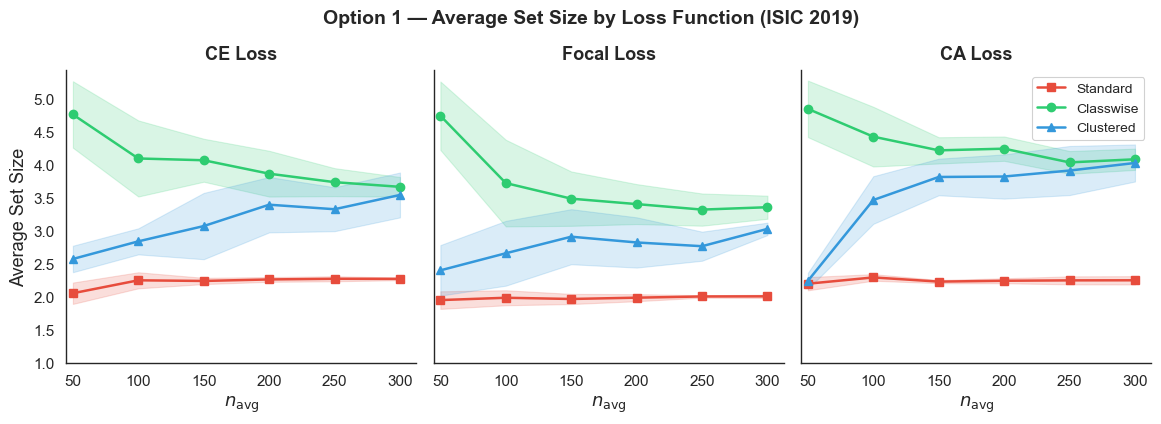

In [44]:
# ============================================================
#  plot_option1_final_v2_avgsize.py
#  Option 1 — 1x3 grid: CE Loss | Focal Loss | CA Loss
#  Fixed: APS score function, AvgSize metric, ISIC dataset
#  Style: matches reference figure
# ============================================================

import sys; sys.path.append("../")
from utils.experiment_utils import *
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ── Settings ──────────────────────────────────────────────────────────────────
save_folder       = r'C:/Anum/Experiments/0002-Conformal-Pred-Classification/GitHub/training/new/conformal/results/paper/varying_n/'
dataset_list      = ['isic-ce', 'isic-focal', 'isic-cp-aware']
cal_sampling      = 'random'
n_list            = [50, 100, 150, 200, 250, 300]
method_list       = ['standard', 'classwise', 'cluster_random']
expected_num_seeds = 5

SCORE     = 'RAPS'
# UPDATE THIS if your dataframe uses a different key (e.g., 'avg_size', 'mean_size')
METRIC    = 'avg_set_size' 
FONT_SIZE = 13

# ── Display names ─────────────────────────────────────────────────────────────
loss_to_label = {
    'isic-ce':       'CE Loss',
    'isic-cp-aware': 'CA Loss',
    'isic-focal' :   'Focal Loss'
}

method_to_name = {
    'standard':       'Standard',
    'classwise':      'Classwise',
    'cluster_random': 'Clustered',
}

method_to_color = {
    'standard':       '#e74c3c',
    'classwise':      '#2ecc71',
    'cluster_random': '#3498db',
}

method_to_marker = {
    'standard':       's',
    'classwise':      'o',
    'cluster_random': '^',
}

# ── Plot style ────────────────────────────────────────────────────────────────
sns.set_style('white', {
    'axes.spines.right': False,
    'axes.spines.top':   False,
    #'grid.linestyle':    '--',
    #'grid.alpha':        0.4,
})
sns.set_context('paper')

# ── Line plot helper ──────────────────────────────────────────────────────────
def make_line_plot(aggregated_results, ax, metric):
    for method in method_list:
        x  = n_list
        y  = np.array(aggregated_results[f'{metric}_mean'][method])
        se = np.array(aggregated_results[f'{metric}_se'][method])

        ax.plot(
            x, y,
            marker=method_to_marker[method],
            label=method_to_name[method],
            color=method_to_color[method],
            markersize=6,
            linewidth=1.8,
            zorder=3
        )
        ax.fill_between(
            x,
            y - 1.96 * se,
            y + 1.96 * se,
            color=method_to_color[method],
            alpha=0.18,
            zorder=2
        )

    ax.set_xlabel('$n_{\\mathrm{avg}}$', fontsize=FONT_SIZE)
    ax.set_xticks(n_list)
    ax.set_xlim(left=45)
    ax.tick_params(labelsize=FONT_SIZE - 2)

# ── Main plot ─────────────────────────────────────────────────────────────────
fig, axs = plt.subplots(
    1, len(dataset_list),
    figsize=(14, 3.8),
    gridspec_kw={'wspace': 0.05}
)

for j, dataset_name in enumerate(dataset_list):

    ax = axs[j]

    # Initialise result containers
    aggregated_results = {
        f'{METRIC}_mean': {m: [] for m in method_list},
        f'{METRIC}_se':   {m: [] for m in method_list},
    }

    # Aggregate across n values
    for n_totalcal in n_list:

        curr_folder = (
            f'{save_folder}/{dataset_name}/{cal_sampling}_calset'
            f'/n_totalcal={n_totalcal}/score={SCORE}'
        )

        df = average_results_across_seeds(
            curr_folder,
            print_results=False,
            display_table=False,
            methods=method_list,
            max_seeds=expected_num_seeds
        )

        for method in method_list:
            for suffix in ['mean', 'se']:
                aggregated_results[f'{METRIC}_{suffix}'][method].append(
                    df[f'{METRIC}_{suffix}'][df['method'] == method].values[0]
                )

    # Draw
    make_line_plot(aggregated_results, ax, METRIC)

    # Panel title
    ax.set_title(
        loss_to_label[dataset_name],
        fontsize=FONT_SIZE,
        fontweight='bold',
        pad=8
    )

    # Y-axis: label + ticks on leftmost only
    if j == 0:
        ax.set_ylabel('Average Set Size', fontsize=FONT_SIZE)
    else:
        ax.set_ylabel('')
        ax.set_yticks([])
        ax.tick_params(left=False)

    # Allow matplotlib to autoscale the Y-axis based on the set sizes, 
    # but ensure it starts at 1 (the minimum possible set size).
    ax.set_ylim(bottom=1.0)

    # Remove right/top spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Legend inside top-right of rightmost panel
axs[-1].legend(
    frameon=True,
    fontsize=FONT_SIZE - 3,
    loc='upper right',
    framealpha=0.9,
    edgecolor='#cccccc'
)

# Main title (Updated to reflect AvgSize and ISIC based on the dataset_list)
fig.suptitle(
    'Option 1 — Average Set Size by Loss Function (ISIC 2019)',
    fontsize=FONT_SIZE + 1,
    fontweight='bold',
    y=1.04
)

plt.tight_layout()

# ── Save ──────────────────────────────────────────────────────────────────────
out_dir = './figures/isic'
os.makedirs(out_dir, exist_ok=True)

for ext in ['pdf', 'png']:
    save_path = os.path.join(out_dir, f'isic_option1_avgsize_{SCORE}.{ext}')
    plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
    print(f'Saved: {save_path}')

plt.show()


Generating MICCAI-Ready 3x3 Master Coverage Chart...
Saved Master MICCAI-ready plot to: ./figures/MICCAI_Master_3x3_Coverage_RAPS_n150.pdf


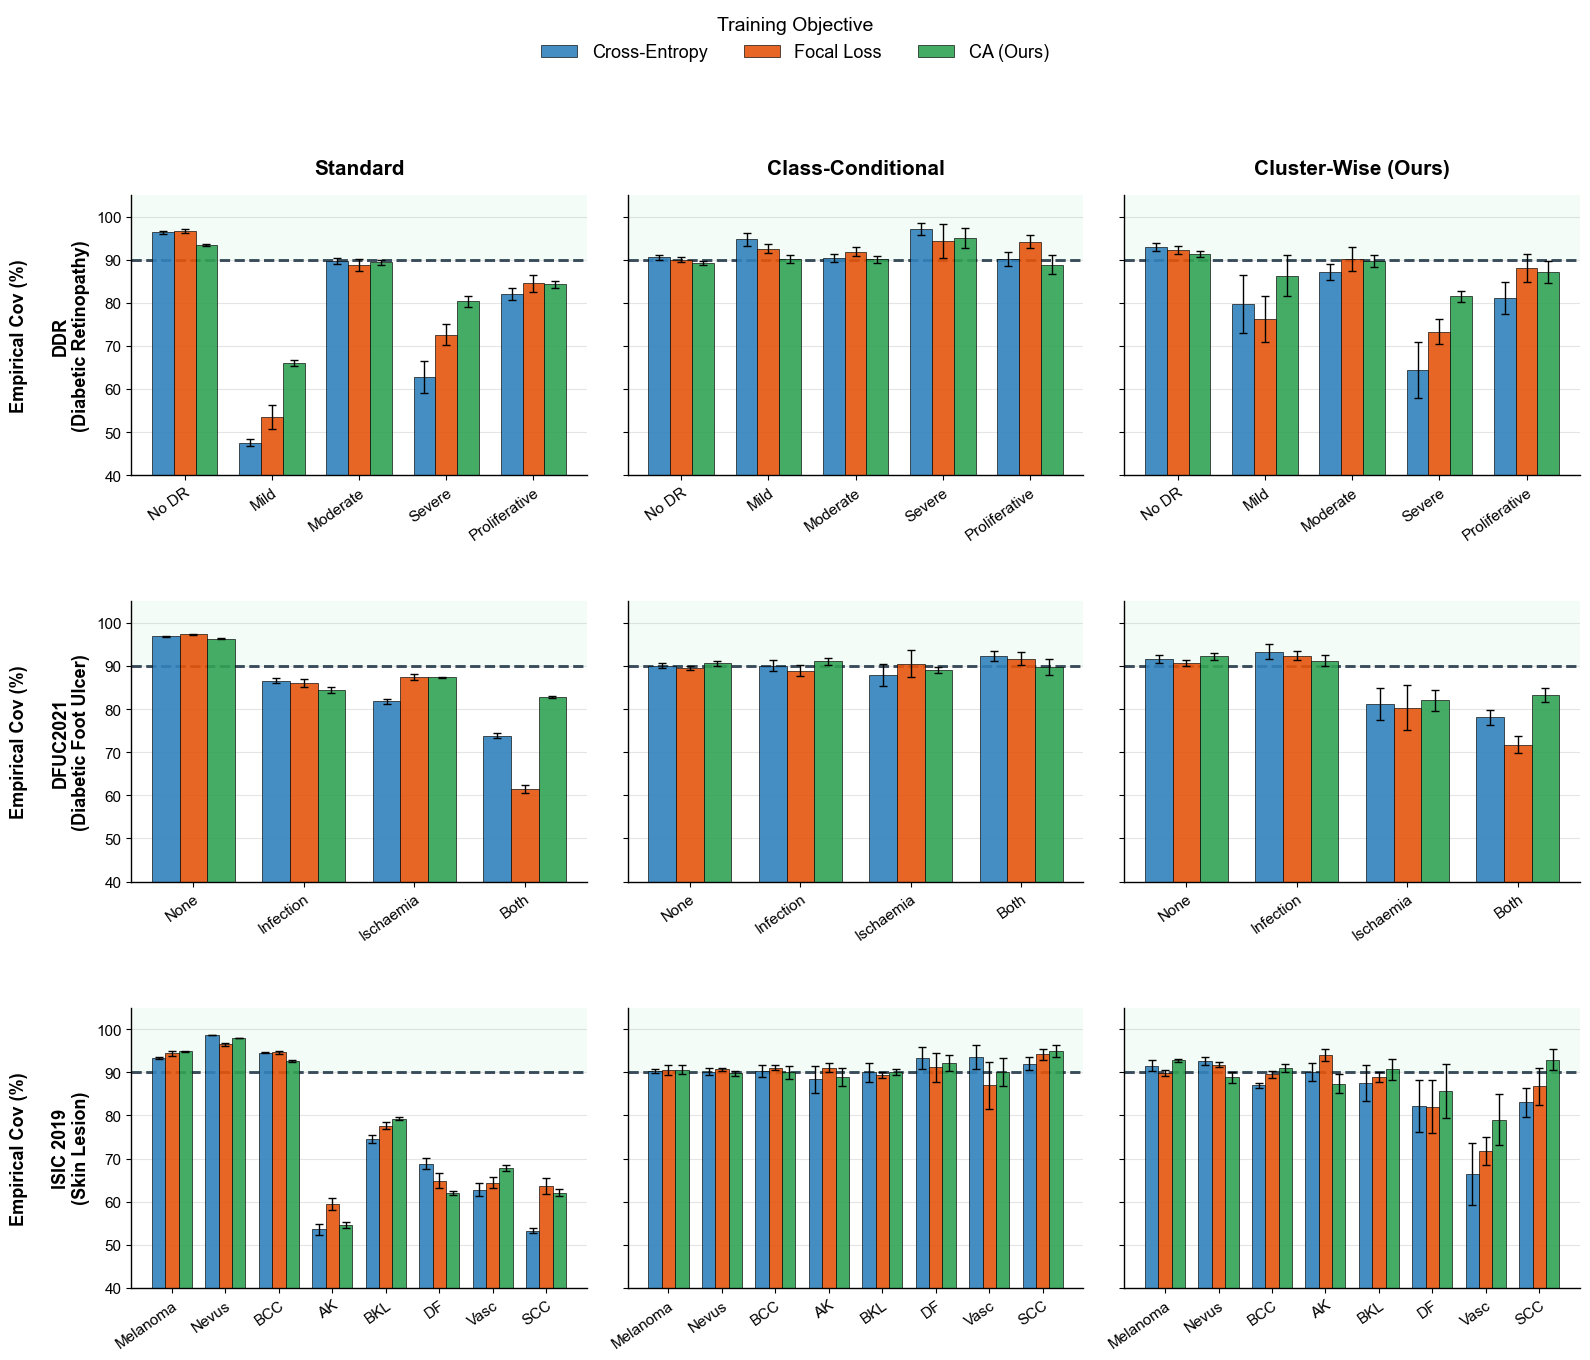

In [128]:

import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

print("\n" + "=" * 60)
print("Generating MICCAI-Ready 3x3 Master Coverage Chart...")
print("=" * 60)

# --- 1. Global Academic Plotting Style ---
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'DejaVu Sans'],
    'axes.labelsize': 13,
    'axes.titlesize': 14,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'axes.linewidth': 1.0,        
    'axes.spines.top': False,     
    'axes.spines.right': False,   
    'legend.fontsize': 13,
    'legend.frameon': False       
})

# --- 2. Master Configurations ---
save_folder = r'C:\Anum\Experiments\0002-Conformal-Pred-Classification\GitHub\training\new\conformal\results\paper\varying_n'
cal_sampling = 'random'
expected_num_seeds = 5

plot_score_func = 'RAPS'     
plot_n_val = 150             

methods_to_plot = ['standard', 'classwise', 'cluster_random']
method_display_names = ['Standard', 'Class-Conditional', 'Cluster-Wise (Ours)']

# Standardized labels and colors across all datasets
model_labels = ['Cross-Entropy', 'Focal Loss', 'CA (Ours)']
model_colors = ['#3182bd', '#e6550d', '#31a354'] # Deep Blue, Warm Rust, Forest Green

# Define the structure for the 3 rows
datasets_info = [
    {
        'title': 'DDR\n(Diabetic Retinopathy)',
        'dirs': ['ddr-ce', 'ddr-focal', 'ddr-cp-aware'],
        'classes': ['No DR', 'Mild', 'Moderate', 'Severe', 'Proliferative']
    },
    {
        'title': 'DFUC2021\n(Diabetic Foot Ulcer)',
        'dirs': ['dfuc-ce', 'dfuc-focal', 'dfuc-cp-aware'],
        'classes': ['None', 'Infection', 'Ischaemia', 'Both']
    },
    {
        'title': 'ISIC 2019\n(Skin Lesion)',
        'dirs': ['isic-ce', 'isic-focal', 'isic-cp-aware'],
        'classes': ['Melanoma', 'Nevus', 'BCC', 'AK', 'BKL', 'DF', 'Vasc', 'SCC']
    }
]

# --- 3. Master Plotting Function ---
def plot_miccai_master_grid(score_function, n_totalcal, save_fig=False, fig_folder='./figures'):
    
    # Create a 3x3 grid. sharey=True perfectly aligns the Y-axis globally.
    fig, axes = plt.subplots(3, 3, figsize=(16, 13), sharey=True)

    # Loop over Rows (Datasets)
    for row_idx, ds_info in enumerate(datasets_info):
        num_actual_classes = len(ds_info['classes'])
        x = np.arange(num_actual_classes)
        width = 0.25
        offsets = [-width, 0, width]
        
        # Loop over Columns (Conformal Methods)
        for col_idx, method in enumerate(methods_to_plot):
            ax = axes[row_idx, col_idx]
            
            # Load and aggregate data
            for model_idx, dir_name in enumerate(ds_info['dirs']):
                model_covs = []
                for seed in range(expected_num_seeds):
                    pth = (f'{save_folder}/{dir_name}/{cal_sampling}_calset'
                           f'/n_totalcal={n_totalcal}/score={score_function}'
                           f'/seed={seed}_allresults.pkl')
                    try:
                        with open(pth, 'rb') as f:
                            results = pickle.load(f)
                        raw_cov = results[method][2]['raw_class_coverages']
                        model_covs.append(raw_cov)
                    except Exception:
                        pass
                
                # Pad missing seeds
                while len(model_covs) < expected_num_seeds:
                    model_covs.append(np.full(num_actual_classes, np.nan))
                    
                covs_array = np.array(model_covs)
                means = np.nanmean(covs_array, axis=0) * 100
                ses = np.nanstd(covs_array, axis=0) / np.sqrt(expected_num_seeds) * 100

                # Plot the bars
                ax.bar(x + offsets[model_idx], means, width,
                       label=model_labels[model_idx] if row_idx == 0 and col_idx == 0 else "", 
                       color=model_colors[model_idx],
                       edgecolor='black', linewidth=0.5, alpha=0.9,
                       yerr=ses, capsize=3, error_kw={'linewidth': 1, 'color': '#333333'})

            # --- Formatting per Subplot ---
            # 90% Target Line and Safe Zone
            ax.axhline(y=90, color='#2c3e50', linestyle='--', linewidth=2, zorder=0)
            ax.axhspan(90, 105, facecolor='#2ecc71', alpha=0.05, zorder=0)

            ax.set_xticks(x)
            
            # X-Axis Labels (Only show class names clearly)
            ax.set_xticklabels(ds_info['classes'], rotation=35, ha='right', rotation_mode='anchor')
            
            # Column Titles (Only on Top Row)
            if row_idx == 0:
                ax.set_title(method_display_names[col_idx], pad=15, fontweight='bold', fontsize=15)
                
            # Row Labels (Only on Leftmost Column)
            if col_idx == 0:
                ax.set_ylabel(f"Empirical Cov (%)\n\n{ds_info['title']}", fontweight='bold', fontsize=13)
            
            ax.set_ylim(40, 105)
            ax.grid(axis='y', linestyle='-', alpha=0.2, color='gray')
            ax.set_axisbelow(True)

    # --- Global Figure Formatting ---
    # Create the global legend at the very top
    handles, labels = axes[0,0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.05), 
               ncol=3, title='Training Objective', title_fontsize=14)

    plt.tight_layout()
    # Adjust spacing to fit the global legend and prevent X-axis labels from overlapping with titles below them
    plt.subplots_adjust(top=0.90, hspace=0.45) 

    if save_fig:
        os.makedirs(fig_folder, exist_ok=True)
        fname = f'{fig_folder}/MICCAI_Master_3x3_Coverage_{score_function}_n{n_totalcal}.pdf'
        plt.savefig(fname, bbox_inches='tight', dpi=300)
        print(f'Saved Master MICCAI-ready plot to: {fname}')

    plt.show()

# --- 4. Execution ---
plot_miccai_master_grid(plot_score_func, plot_n_val, save_fig=True)


Generating MICCAI-Ready 1x3 Cluster-Wise Chart...
Saved 1x3 Cluster-Wise plot to: ./figures/MICCAI_ClusterWise_1x3_RAPS_n150.pdf


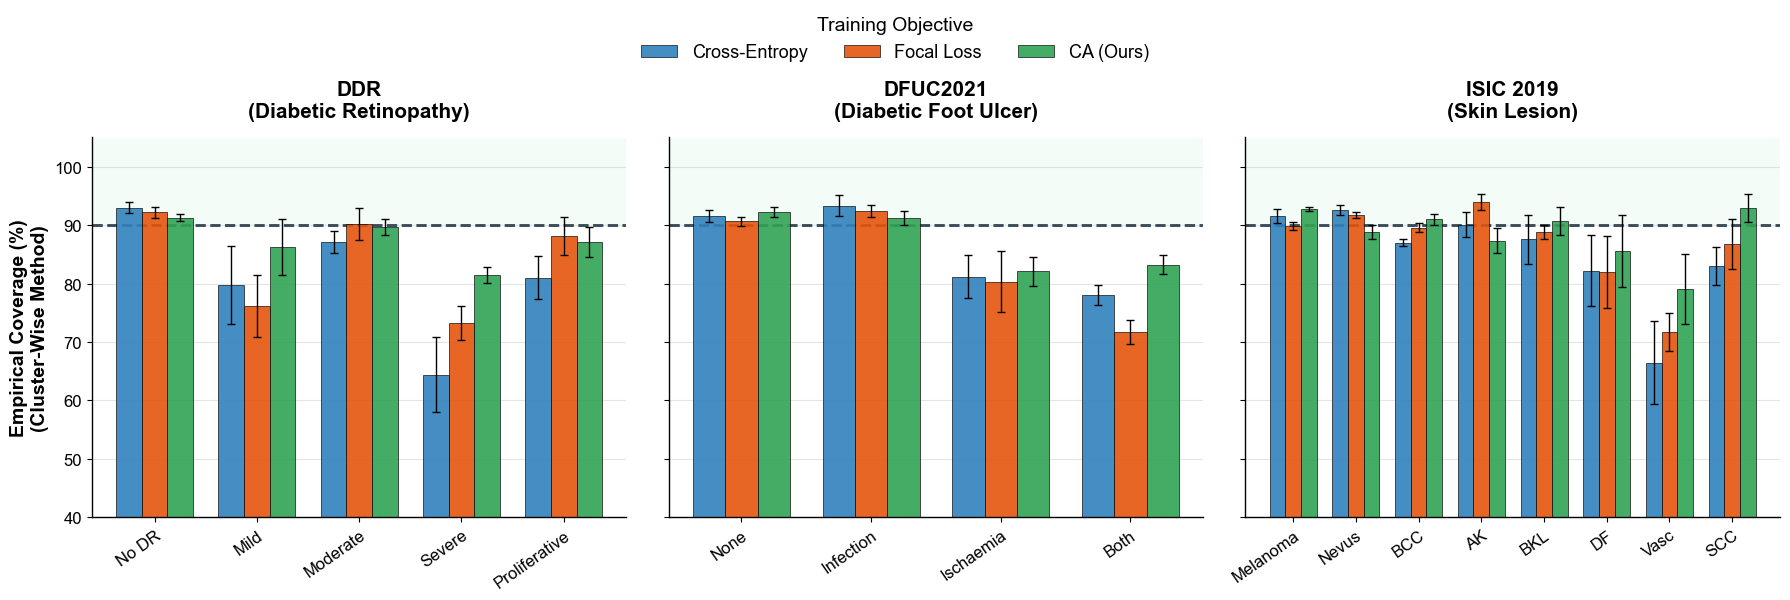

In [130]:
# ============================================================
#  Cell: MICCAI-Worthy 1x3 Cluster-Wise Coverage Chart
# ============================================================
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

print("\n" + "=" * 60)
print("Generating MICCAI-Ready 1x3 Cluster-Wise Chart...")
print("=" * 60)

# --- 1. Global Academic Plotting Style ---
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'DejaVu Sans'],
    'axes.labelsize': 14,
    'axes.titlesize': 15,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'axes.linewidth': 1.0,        
    'axes.spines.top': False,     
    'axes.spines.right': False,   
    'legend.fontsize': 13,
    'legend.frameon': False       
})

# --- 2. Master Configurations ---
save_folder = r'C:\Anum\Experiments\0002-Conformal-Pred-Classification\GitHub\training\new\conformal\results\paper\varying_n'
cal_sampling = 'random'
expected_num_seeds = 5

plot_score_func = 'RAPS'     
plot_n_val = 150             

# We are ONLY plotting the Cluster-Wise method now
target_method = 'cluster_random'

# Standardized labels and colors across all datasets
model_labels = ['Cross-Entropy', 'Focal Loss', 'CA (Ours)']
model_colors = ['#3182bd', '#e6550d', '#31a354'] # Deep Blue, Warm Rust, Forest Green

# Define the structure for the 3 columns
datasets_info = [
    {
        'title': 'DDR\n(Diabetic Retinopathy)',
        'dirs': ['ddr-ce', 'ddr-focal', 'ddr-cp-aware'],
        'classes': ['No DR', 'Mild', 'Moderate', 'Severe', 'Proliferative']
    },
    {
        'title': 'DFUC2021\n(Diabetic Foot Ulcer)',
        'dirs': ['dfuc-ce', 'dfuc-focal', 'dfuc-cp-aware'],
        'classes': ['None', 'Infection', 'Ischaemia', 'Both']
    },
    {
        'title': 'ISIC 2019\n(Skin Lesion)',
        'dirs': ['isic-ce', 'isic-focal', 'isic-cp-aware'],
        'classes': ['Melanoma', 'Nevus', 'BCC', 'AK', 'BKL', 'DF', 'Vasc', 'SCC']
    }
]

# --- 3. Plotting Function ---
def plot_miccai_clusterwise_1x3(score_function, n_totalcal, save_fig=False, fig_folder='./figures'):
    
    # Create a 1x3 grid. sharey=True perfectly aligns the Y-axis globally.
    fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), sharey=True)

    # Loop over Columns (Datasets)
    for col_idx, ds_info in enumerate(datasets_info):
        ax = axes[col_idx]
        num_actual_classes = len(ds_info['classes'])
        x = np.arange(num_actual_classes)
        width = 0.25
        offsets = [-width, 0, width]
        
        # Load and aggregate data for the 3 loss functions
        for model_idx, dir_name in enumerate(ds_info['dirs']):
            model_covs = []
            for seed in range(expected_num_seeds):
                pth = (f'{save_folder}/{dir_name}/{cal_sampling}_calset'
                       f'/n_totalcal={n_totalcal}/score={score_function}'
                       f'/seed={seed}_allresults.pkl')
                try:
                    with open(pth, 'rb') as f:
                        results = pickle.load(f)
                    # Force loading only the cluster_random method
                    raw_cov = results[target_method][2]['raw_class_coverages']
                    model_covs.append(raw_cov)
                except Exception:
                    pass
            
            # Pad missing seeds
            while len(model_covs) < expected_num_seeds:
                model_covs.append(np.full(num_actual_classes, np.nan))
                
            covs_array = np.array(model_covs)
            means = np.nanmean(covs_array, axis=0) * 100
            ses = np.nanstd(covs_array, axis=0) / np.sqrt(expected_num_seeds) * 100

            # Plot the bars
            ax.bar(x + offsets[model_idx], means, width,
                   label=model_labels[model_idx] if col_idx == 0 else "", 
                   color=model_colors[model_idx],
                   edgecolor='black', linewidth=0.5, alpha=0.9,
                   yerr=ses, capsize=3, error_kw={'linewidth': 1, 'color': '#333333'})

        # --- Formatting per Subplot ---
        # 90% Target Line and Safe Zone
        ax.axhline(y=90, color='#2c3e50', linestyle='--', linewidth=2, zorder=0)
        ax.axhspan(90, 105, facecolor='#2ecc71', alpha=0.05, zorder=0)

        ax.set_xticks(x)
        
        # X-Axis Labels (Rotate to 35 to accommodate ISIC, align right)
        ax.set_xticklabels(ds_info['classes'], rotation=35, ha='right', rotation_mode='anchor')
        
        # Column Titles (Dataset names)
        ax.set_title(ds_info['title'], pad=15, fontweight='bold', fontsize=15)
            
        # Row Label (Only on Leftmost Column)
        if col_idx == 0:
            ax.set_ylabel(f"Empirical Coverage (%)\n(Cluster-Wise Method)", fontweight='bold', fontsize=14)
        
        ax.set_ylim(40, 105)
        ax.grid(axis='y', linestyle='-', alpha=0.2, color='gray')
        ax.set_axisbelow(True)

    # --- Global Figure Formatting ---
    # Create the global legend at the very top
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.10), 
               ncol=3, title='Training Objective', title_fontsize=14)

    plt.tight_layout()
    # Adjust spacing to fit the global legend
    plt.subplots_adjust(top=0.85) 

    if save_fig:
        os.makedirs(fig_folder, exist_ok=True)
        fname = f'{fig_folder}/MICCAI_ClusterWise_1x3_{score_function}_n{n_totalcal}.pdf'
        plt.savefig(fname, bbox_inches='tight', dpi=300)
        print(f'Saved 1x3 Cluster-Wise plot to: {fname}')

    plt.show()

# --- 4. Execution ---
plot_miccai_clusterwise_1x3(plot_score_func, plot_n_val, save_fig=True)


Generating MICCAI-Ready 1x3 Cluster-Wise Chart...
Saved 1x3 Cluster-Wise plot to: ./figures/MICCAI_ClusterWise_1x3_RAPS_n150.pdf


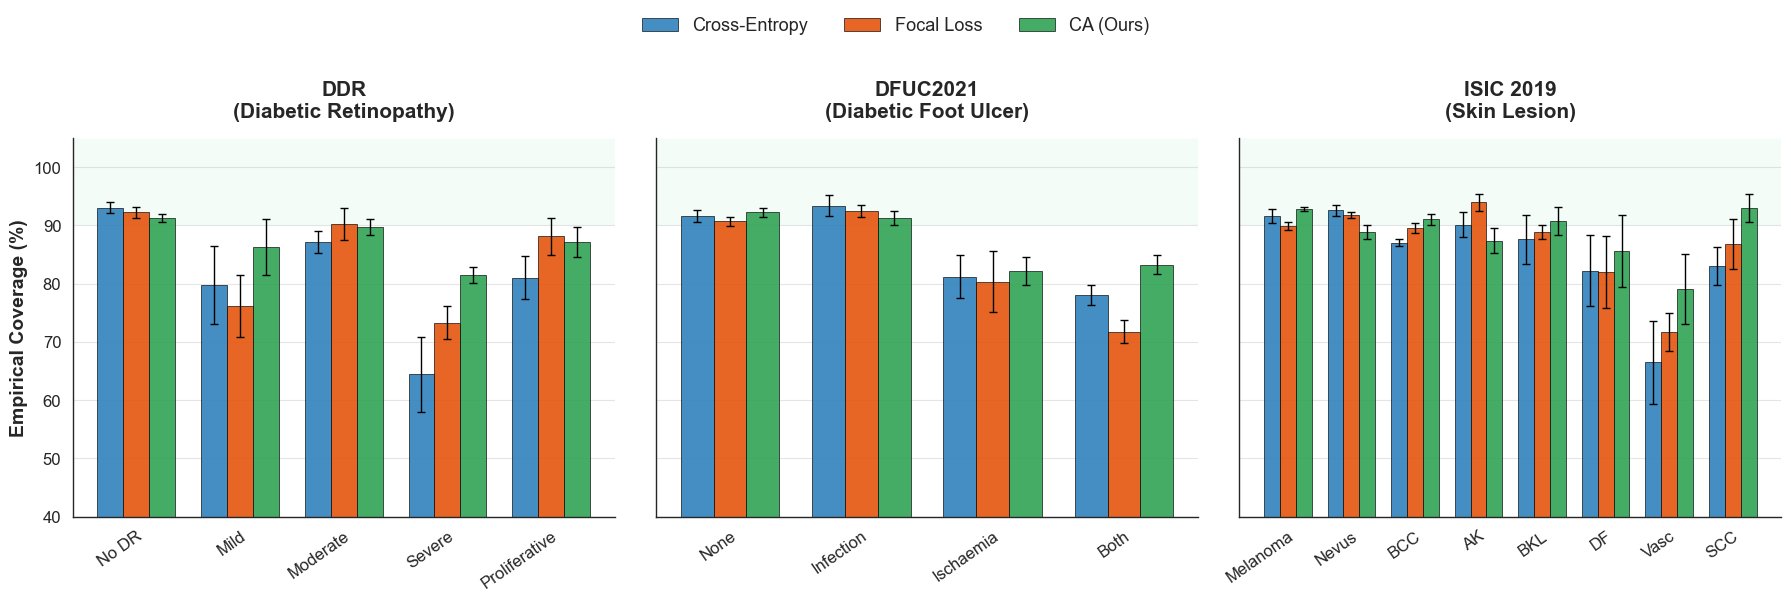

In [45]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

print("\n" + "=" * 60)
print("Generating MICCAI-Ready 1x3 Cluster-Wise Chart...")
print("=" * 60)

# --- 1. Global Academic Plotting Style ---
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'DejaVu Sans'],
    'axes.labelsize': 14,
    'axes.titlesize': 15,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'axes.linewidth': 1.0,        
    'axes.spines.top': False,     
    'axes.spines.right': False,   
    'legend.fontsize': 13,
    'legend.frameon': False       
})

# --- 2. Master Configurations ---
save_folder = r'C:\Anum\Experiments\0002-Conformal-Pred-Classification\GitHub\training\new\conformal\results\paper\varying_n'
cal_sampling = 'random'
expected_num_seeds = 5

plot_score_func = 'RAPS'     
plot_n_val = 150             

# We are ONLY plotting the Cluster-Wise method now
target_method = 'cluster_random'

# Standardized labels and colors across all datasets
model_labels = ['Cross-Entropy', 'Focal Loss', 'CA (Ours)']
model_colors = ['#3182bd', '#e6550d', '#31a354'] # Deep Blue, Warm Rust, Forest Green

# Define the structure for the 3 columns
datasets_info = [
    {
        'title': 'DDR\n(Diabetic Retinopathy)',
        'dirs': ['ddr-ce', 'ddr-focal', 'ddr-cp-aware'],
        'classes': ['No DR', 'Mild', 'Moderate', 'Severe', 'Proliferative']
    },
    {
        'title': 'DFUC2021\n(Diabetic Foot Ulcer)',
        'dirs': ['dfuc-ce', 'dfuc-focal', 'dfuc-cp-aware'],
        'classes': ['None', 'Infection', 'Ischaemia', 'Both']
    },
    {
        'title': 'ISIC 2019\n(Skin Lesion)',
        'dirs': ['isic-ce', 'isic-focal', 'isic-cp-aware'],
        'classes': ['Melanoma', 'Nevus', 'BCC', 'AK', 'BKL', 'DF', 'Vasc', 'SCC']
    }
]

# --- 3. Plotting Function ---
def plot_miccai_clusterwise_1x3(score_function, n_totalcal, save_fig=False, fig_folder='./figures'):
    
    # Create a 1x3 grid. sharey=True perfectly aligns the Y-axis globally.
    fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), sharey=True)

    # Loop over Columns (Datasets)
    for col_idx, ds_info in enumerate(datasets_info):
        ax = axes[col_idx]
        num_actual_classes = len(ds_info['classes'])
        x = np.arange(num_actual_classes)
        width = 0.25
        offsets = [-width, 0, width]
        
        # Load and aggregate data for the 3 loss functions
        for model_idx, dir_name in enumerate(ds_info['dirs']):
            model_covs = []
            for seed in range(expected_num_seeds):
                pth = (f'{save_folder}/{dir_name}/{cal_sampling}_calset'
                       f'/n_totalcal={n_totalcal}/score={score_function}'
                       f'/seed={seed}_allresults.pkl')
                try:
                    with open(pth, 'rb') as f:
                        results = pickle.load(f)
                    # Force loading only the cluster_random method
                    raw_cov = results[target_method][2]['raw_class_coverages']
                    model_covs.append(raw_cov)
                except Exception:
                    pass
            
            # Pad missing seeds
            while len(model_covs) < expected_num_seeds:
                model_covs.append(np.full(num_actual_classes, np.nan))
                
            covs_array = np.array(model_covs)
            means = np.nanmean(covs_array, axis=0) * 100
            ses = np.nanstd(covs_array, axis=0) / np.sqrt(expected_num_seeds) * 100

            # Plot the bars
            ax.bar(x + offsets[model_idx], means, width,
                   label=model_labels[model_idx] if col_idx == 0 else "", 
                   color=model_colors[model_idx],
                   edgecolor='black', linewidth=0.5, alpha=0.9,
                   yerr=ses, capsize=3, error_kw={'linewidth': 1, 'color': '#333333'})

        # --- Formatting per Subplot ---
        # 90% Safe Zone (Dashed line removed)
        ax.axhspan(90, 105, facecolor='#2ecc71', alpha=0.05, zorder=0)

        ax.set_xticks(x)
        
        # X-Axis Labels (Rotate to 35 to accommodate ISIC, align right)
        ax.set_xticklabels(ds_info['classes'], rotation=35, ha='right', rotation_mode='anchor')
        
        # Column Titles (Dataset names)
        ax.set_title(ds_info['title'], pad=15, fontweight='bold', fontsize=15)
            
        # Row Label (Only on Leftmost Column)
        if col_idx == 0:
            ax.set_ylabel(f"Empirical Coverage (%)", fontweight='bold', fontsize=14)
        
        ax.set_ylim(40, 105)
        ax.grid(axis='y', linestyle='-', alpha=0.2, color='gray')
        ax.set_axisbelow(True)

    # --- Global Figure Formatting ---
    # Create the global legend at the very top
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.10), 
               ncol=3, title='', title_fontsize=14)

    plt.tight_layout()
    # Adjust spacing to fit the global legend
    plt.subplots_adjust(top=0.85) 

    if save_fig:
        os.makedirs(fig_folder, exist_ok=True)
        fname = f'{fig_folder}/MICCAI_ClusterWise_1x3_{score_function}_n{n_totalcal}.pdf'
        plt.savefig(fname, bbox_inches='tight', dpi=300)
        print(f'Saved 1x3 Cluster-Wise plot to: {fname}')

    plt.show()

# --- 4. Execution ---
plot_miccai_clusterwise_1x3(plot_score_func, plot_n_val, save_fig=True)

C:\Users\24856613\AppData\Local\Temp\ipykernel_7932\3245002986.py:199: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved: ./figures/miccai_final\miccai_3x3_covgap_n150_RAPS.pdf
Saved: ./figures/miccai_final\miccai_3x3_covgap_n150_RAPS.png


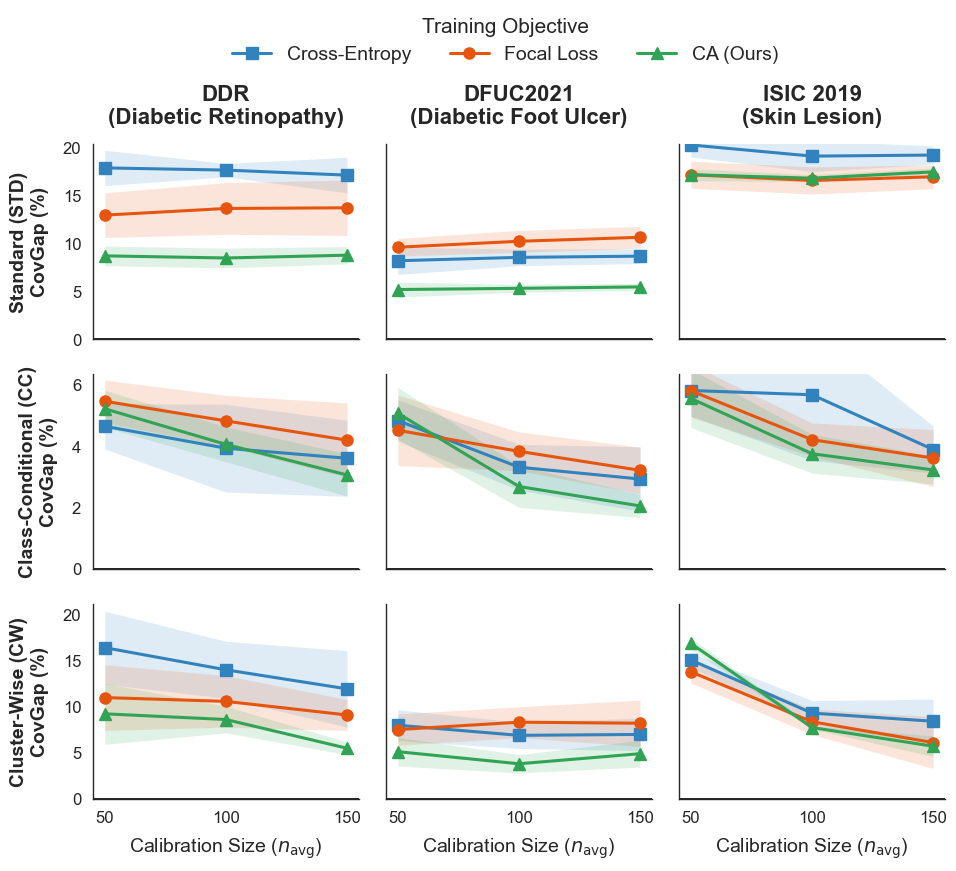

In [55]:
# ============================================================
#  plot_all_3x3_covgap_miccai_low_data.py
#  3x3 grid: Rows (CP Methods) x Columns (Datasets)
#  Lines: CE Loss | Focal Loss | CA Loss
#  Metric: CovGap (Truncated to n_avg=150)
# ============================================================

import sys; sys.path.append("../")
from utils.experiment_utils import *
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ── Settings ──────────────────────────────────────────────────────────────────
save_folder        = r'C:/Anum/Experiments/0002-Conformal-Pred-Classification/GitHub/training/new/conformal/results/paper/varying_n/'
cal_sampling       = 'random'
# TRUNCATED N_LIST
n_list             = [50, 100, 150] 
expected_num_seeds = 5

SCORE    = 'RAPS'
METRIC   = 'class_cov_gap'

# Scaled up for readability when the image is shrunk in LaTeX
FONT_SIZE = 14 
TITLE_SIZE = 16

# ── Structure Definitions ─────────────────────────────────────────────────────
dataset_list = ['ddr', 'dfuc', 'isic']
method_list  = ['standard', 'classwise', 'cluster_random']
loss_list    = ['ce', 'focal', 'cp-aware']

dataset_to_title = {
    'ddr':  'DDR\n(Diabetic Retinopathy)',
    'dfuc': 'DFUC2021\n(Diabetic Foot Ulcer)',
    'isic': 'ISIC 2019\n(Skin Lesion)'
}

method_to_name = {
    'standard':       'Standard (STD)',
    'classwise':      'Class-Conditional (CC)',
    'cluster_random': 'Cluster-Wise (CW)'
}

loss_to_name = {
    'ce':       'Cross-Entropy',
    'focal':    'Focal Loss',
    'cp-aware': 'CA (Ours)'
}

# Colorblind-friendly, highly distinct academic palette
loss_to_color = {
    'ce':       '#3182bd', # Deep Blue
    'focal':    '#e6550d', # Warm Rust
    'cp-aware': '#31a354', # Forest Green
}

loss_to_marker = {
    'ce':       's',
    'focal':    'o',
    'cp-aware': '^',
}

# ── Plot style ────────────────────────────────────────────────────────────────
# Enforce thicker axes lines for publication scaling
plt.rcParams.update({
    'axes.linewidth': 1.2,
    'xtick.major.width': 1.2,
    'ytick.major.width': 1.2
})

sns.set_style('white', {
    'axes.spines.right': False,
    'axes.spines.top':   False,
})
sns.set_context('paper')

# ── Line plot helper ──────────────────────────────────────────────────────────
def make_line_plot(aggregated_results, ax, metric):
    for loss in loss_list:
        x  = n_list
        y  = np.array(aggregated_results[f'{metric}_mean'][loss])
        se = np.array(aggregated_results[f'{metric}_se'][loss])

        ax.plot(
            x, y,
            marker=loss_to_marker[loss],
            label=loss_to_name[loss],
            color=loss_to_color[loss],
            markersize=8, # Slightly larger markers since we have fewer points
            linewidth=2.2,
            zorder=3
        )
        ax.fill_between(
            x,
            y - 1.96 * se,
            y + 1.96 * se,
            color=loss_to_color[loss],
            alpha=0.15, 
            zorder=2,
            linewidth=0
        )

    ax.set_xticks(n_list)
    # TIGHTER XLIM FOR LOW-DATA REGIME
    ax.set_xlim(left=45, right=155) 
    ax.tick_params(labelsize=FONT_SIZE - 2)

# ── Main plot ─────────────────────────────────────────────────────────────────
# Slightly narrowed width (11 instead of 12) so lines don't look unnaturally stretched
fig, axs = plt.subplots(
    len(method_list), len(dataset_list),
    figsize=(11, 8.5), 
    gridspec_kw={'wspace': 0.1, 'hspace': 0.18},
    sharex=True, sharey='row'
)

for i, method in enumerate(method_list):
    for j, dataset in enumerate(dataset_list):
        ax = axs[i, j]

        # Initialise result containers for the 3 losses
        aggregated_results = {
            f'{METRIC}_mean': {loss: [] for loss in loss_list},
            f'{METRIC}_se':   {loss: [] for loss in loss_list},
        }

        # Extract data
        for loss in loss_list:
            folder_name = f"{dataset}-{loss}"
            
            for n_totalcal in n_list:
                curr_folder = (
                    f'{save_folder}/{folder_name}/{cal_sampling}_calset'
                    f'/n_totalcal={n_totalcal}/score={SCORE}'
                )

                df = average_results_across_seeds(
                    curr_folder,
                    print_results=False,
                    display_table=False,
                    methods=[method], 
                    max_seeds=expected_num_seeds
                )

                for suffix in ['mean', 'se']:
                    val = df[f'{METRIC}_{suffix}'][df['method'] == method].values[0]
                    aggregated_results[f'{METRIC}_{suffix}'][loss].append(val)

        # Draw the lines
        make_line_plot(aggregated_results, ax, METRIC)

        # Force grid off
        ax.grid(False)

        # Column Titles (Top row only)
        if i == 0:
            ax.set_title(
                dataset_to_title[dataset],
                fontsize=TITLE_SIZE,
                fontweight='bold',
                pad=15
            )

        # Y-Axis Labels (Leftmost column only)
        if j == 0:
            ax.set_ylabel(f'{method_to_name[method]}\nCovGap (%)', 
                          fontsize=FONT_SIZE, fontweight='bold', labelpad=10)
        else:
            ax.set_ylabel('')
            ax.tick_params(left=False)

        # X-Axis Labels (Bottom row only)
        if i == len(method_list) - 1:
            ax.set_xlabel('Calibration Size ($n_{\\mathrm{avg}}$)', fontsize=FONT_SIZE, labelpad=8)

        ax.set_ylim(bottom=0)
        
        # Add a subtle zero-line reference
        ax.axhline(y=0, color='black', linewidth=1.2, zorder=1)

# ── Global Legend ─────────────────────────────────────────────────────────────
# Extract handles and labels from the very first axis
handles, labels = axs[0, 0].get_legend_handles_labels()

# Place a single legend above the entire grid, centered.
fig.legend(
    handles, labels, 
    loc='upper center', 
    bbox_to_anchor=(0.5, 1.05), # Pushes it just above the subplots
    ncol=3, 
    frameon=False, 
    fontsize=FONT_SIZE,
    title='Training Objective',
    title_fontsize=FONT_SIZE + 1
)

plt.tight_layout()

# ── Save ──────────────────────────────────────────────────────────────────────
out_dir = './figures/miccai_final'
os.makedirs(out_dir, exist_ok=True)

# Save as PDF for LaTeX 
for ext in ['pdf', 'png']:
    save_path = os.path.join(out_dir, f'miccai_3x3_covgap_n150_{SCORE}.{ext}')
    plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
    print(f'Saved: {save_path}')

plt.show()

C:\Users\24856613\AppData\Local\Temp\ipykernel_7932\298889238.py:190: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved: ./figures/miccai_final\miccai_1x3_cw_covgap_n150_RAPS.pdf
Saved: ./figures/miccai_final\miccai_1x3_cw_covgap_n150_RAPS.png


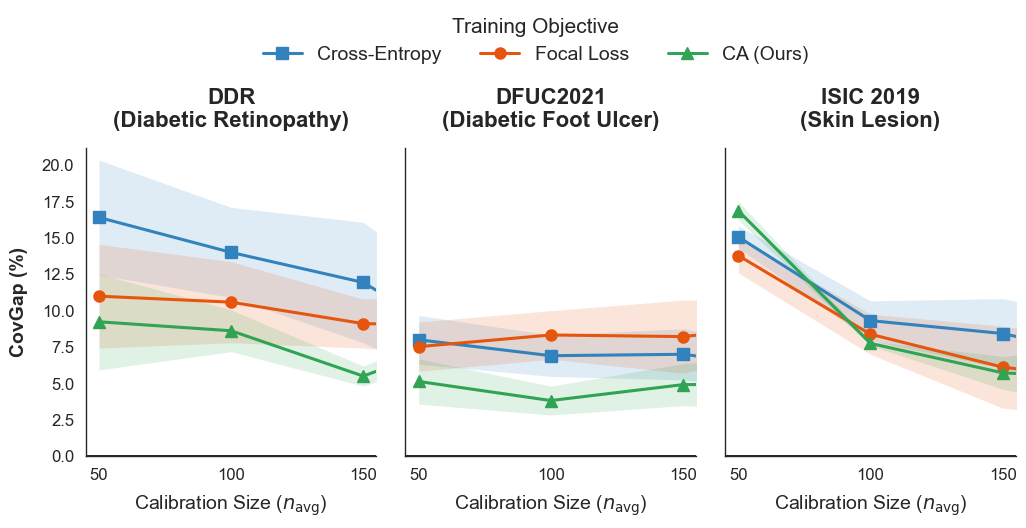

In [58]:
# ============================================================
#  plot_cw_1x3_covgap_miccai_low_data.py
#  1x3 grid: 1 Row (Cluster-Wise) x 3 Columns (Datasets)
#  Lines: CE Loss | Focal Loss | CA Loss
#  Metric: CovGap (Truncated to n_avg=150)
# ============================================================

import sys; sys.path.append("../")
from utils.experiment_utils import *
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ── Settings ──────────────────────────────────────────────────────────────────
save_folder        = r'C:/Anum/Experiments/0002-Conformal-Pred-Classification/GitHub/training/new/conformal/results/paper/varying_n/'
cal_sampling       = 'random'
n_list             = [50, 100, 150,200,250,300] # TRUNCATED
expected_num_seeds = 5

SCORE    = 'RAPS'
METRIC   = 'class_cov_gap'

# We are only plotting Cluster-Wise now
TARGET_METHOD = 'cluster_random' 

# Scaled up for readability when the image is shrunk in LaTeX
FONT_SIZE = 14 
TITLE_SIZE = 16

# ── Structure Definitions ─────────────────────────────────────────────────────
dataset_list = ['ddr', 'dfuc', 'isic']
loss_list    = ['ce', 'focal', 'cp-aware']

dataset_to_title = {
    'ddr':  'DDR\n(Diabetic Retinopathy)',
    'dfuc': 'DFUC2021\n(Diabetic Foot Ulcer)',
    'isic': 'ISIC 2019\n(Skin Lesion)'
}

loss_to_name = {
    'ce':       'Cross-Entropy',
    'focal':    'Focal Loss',
    'cp-aware': 'CA (Ours)'
}

# Colorblind-friendly, highly distinct academic palette
loss_to_color = {
    'ce':       '#3182bd', # Deep Blue
    'focal':    '#e6550d', # Warm Rust
    'cp-aware': '#31a354', # Forest Green
}

loss_to_marker = {
    'ce':       's',
    'focal':    'o',
    'cp-aware': '^',
}

# ── Plot style ────────────────────────────────────────────────────────────────
# Enforce thicker axes lines for publication scaling
plt.rcParams.update({
    'axes.linewidth': 1.2,
    'xtick.major.width': 1.2,
    'ytick.major.width': 1.2
})

sns.set_style('white', {
    'axes.spines.right': False,
    'axes.spines.top':   False,
})
sns.set_context('paper')

# ── Line plot helper ──────────────────────────────────────────────────────────
def make_line_plot(aggregated_results, ax, metric):
    for loss in loss_list:
        x  = n_list
        y  = np.array(aggregated_results[f'{metric}_mean'][loss])
        se = np.array(aggregated_results[f'{metric}_se'][loss])

        ax.plot(
            x, y,
            marker=loss_to_marker[loss],
            label=loss_to_name[loss],
            color=loss_to_color[loss],
            markersize=8,
            linewidth=2.2,
            zorder=3
        )
        ax.fill_between(
            x,
            y - 1.96 * se,
            y + 1.96 * se,
            color=loss_to_color[loss],
            alpha=0.15, 
            zorder=2,
            linewidth=0
        )

    ax.set_xticks(n_list)
    ax.set_xlim(left=45, right=155) 
    ax.tick_params(labelsize=FONT_SIZE - 2)

# ── Main plot ─────────────────────────────────────────────────────────────────
# Aspect ratio adjusted for a single row 1x3 grid
fig, axs = plt.subplots(
    1, len(dataset_list),
    figsize=(12, 4), 
    gridspec_kw={'wspace': 0.1},
    sharey=True
)

for j, dataset in enumerate(dataset_list):
    ax = axs[j]

    # Initialise result containers for the 3 losses
    aggregated_results = {
        f'{METRIC}_mean': {loss: [] for loss in loss_list},
        f'{METRIC}_se':   {loss: [] for loss in loss_list},
    }

    # Extract data
    for loss in loss_list:
        folder_name = f"{dataset}-{loss}"
        
        for n_totalcal in n_list:
            curr_folder = (
                f'{save_folder}/{folder_name}/{cal_sampling}_calset'
                f'/n_totalcal={n_totalcal}/score={SCORE}'
            )

            df = average_results_across_seeds(
                curr_folder,
                print_results=False,
                display_table=False,
                methods=[TARGET_METHOD], 
                max_seeds=expected_num_seeds
            )

            for suffix in ['mean', 'se']:
                val = df[f'{METRIC}_{suffix}'][df['method'] == TARGET_METHOD].values[0]
                aggregated_results[f'{METRIC}_{suffix}'][loss].append(val)

    # Draw the lines
    make_line_plot(aggregated_results, ax, METRIC)

    # Force grid off
    ax.grid(False)

    # Column Titles
    ax.set_title(
        dataset_to_title[dataset],
        fontsize=TITLE_SIZE,
        fontweight='bold',
        pad=15
    )

    # Y-Axis Labels (Leftmost column only)
    if j == 0:
        ax.set_ylabel('CovGap (%)', 
                      fontsize=FONT_SIZE, fontweight='bold', labelpad=10)
    else:
        ax.set_ylabel('')
        ax.tick_params(left=False)

    # X-Axis Labels (Applied to all columns since it's only one row)
    ax.set_xlabel('Calibration Size ($n_{\\mathrm{avg}}$)', fontsize=FONT_SIZE, labelpad=8)

    ax.set_ylim(bottom=0)
    
    # Add a subtle zero-line reference
    ax.axhline(y=0, color='black', linewidth=1.2, zorder=1)

# ── Global Legend ─────────────────────────────────────────────────────────────
# Extract handles and labels from the first axis
handles, labels = axs[0].get_legend_handles_labels()

# Place a single legend above the grid, centered.
fig.legend(
    handles, labels, 
    loc='upper center', 
    bbox_to_anchor=(0.5, 1.25), # Pushed higher to clear the single row's titles
    ncol=3, 
    frameon=False, 
    fontsize=FONT_SIZE,
    title='Training Objective',
    title_fontsize=FONT_SIZE + 1
)

plt.tight_layout()

# ── Save ──────────────────────────────────────────────────────────────────────
out_dir = './figures/miccai_final'
os.makedirs(out_dir, exist_ok=True)

# Save as PDF for LaTeX
for ext in ['pdf', 'png']:
    save_path = os.path.join(out_dir, f'miccai_1x3_cw_covgap_n150_{SCORE}.{ext}')
    plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
    print(f'Saved: {save_path}')

plt.show()